# Imports

In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import statsmodels.stats.api as sms
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil
import os
pd.set_option('future.no_silent_downcasting', True)

## Load Data
### Data source: [Inside Airbnb](http://insideairbnb.com/get-the-data) 
### — New York City, May 2025 snapshot.

In [2]:
path = "data/"

listings = pd.read_csv(path + "listings.csv.gz", compression='gzip', low_memory=False)
calendar = pd.read_csv(path + "calendar.csv.gz", compression='gzip', low_memory=False)

print(f'Listings : {listings.shape}')
print(f'Calendar : {calendar.shape}')


Listings : (37018, 79)
Calendar : (13499675, 7)


## Exploratory Data Analysis: Calendar

In [3]:
calendar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13499675 entries, 0 to 13499674
Data columns (total 7 columns):
 #   Column          Dtype  
---  ------          -----  
 0   listing_id      int64  
 1   date            object 
 2   available       object 
 3   price           object 
 4   adjusted_price  object 
 5   minimum_nights  float64
 6   maximum_nights  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 721.0+ MB


In [4]:
calendar.head(9)

,listing_id,date,available,price,adjusted_price,minimum_nights,maximum_nights
0,2539,2025-05-02,f,$299.00,NaN,30.0,730.0
1,2539,2025-05-03,f,$299.00,NaN,30.0,730.0
2,2539,2025-05-04,f,$299.00,NaN,30.0,730.0
3,2539,2025-05-05,f,$299.00,NaN,30.0,730.0
4,2539,2025-05-06,f,$299.00,NaN,30.0,730.0
5,2539,2025-05-07,f,$299.00,NaN,30.0,730.0
6,2539,2025-05-08,f,$299.00,NaN,30.0,730.0
7,2539,2025-05-09,f,$299.00,NaN,30.0,730.0
8,2539,2025-05-10,f,$299.00,NaN,30.0,730.0


In [5]:
calendar.describe()

,listing_id,minimum_nights,maximum_nights
count,1.349968e+07,1.349599e+07,1.349599e+07
mean,4.372466e+17,3.024958e+01,8.155863e+05
std,5.143709e+17,4.157294e+01,4.181157e+07
min,2.539000e+03,1.000000e+00,1.000000e+00
25%,2.138494e+07,3.000000e+01,3.650000e+02
50%,5.037663e+07,3.000000e+01,7.000000e+02
75%,9.257247e+17,3.000000e+01,1.125000e+03
max,1.410916e+18,1.250000e+03,2.147484e+09


In [6]:
# Null percentages per column in calendar sorted from highest to lowest 
calendar_null_percent= (calendar.isnull().sum()/len(calendar)*100).round(2)
print(calendar_null_percent.sort_values(ascending = False).to_string())

adjusted_price    99.99
minimum_nights     0.03
maximum_nights     0.03
listing_id         0.00
date               0.00
available          0.00
price              0.00


# Exploratory Data Analysis: Listings

In [7]:
listings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37018 entries, 0 to 37017
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            37018 non-null  int64  
 1   listing_url                                   37018 non-null  object 
 2   scrape_id                                     37018 non-null  int64  
 3   last_scraped                                  37018 non-null  object 
 4   source                                        37018 non-null  object 
 5   name                                          37016 non-null  object 
 6   description                                   36011 non-null  object 
 7   neighborhood_overview                         19575 non-null  object 
 8   picture_url                                   37017 non-null  object 
 9   host_id                                       37018 non-null 

In [8]:
listings.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,2539,https://www.airbnb.com/rooms/2539,20250501160219,2025-05-02,previous scrape,Superfast Wi-Fi. Clean & quiet home by the park,Renovated apartment home in an elevator buildi...,Close to Prospect Park and Historic Ditmas Park,https://a0.muscache.com/pictures/hosting/Hosti...,2787,...,5.0,4.75,4.88,NaN,f,5,1,4,0,0.08
1,2595,https://www.airbnb.com/rooms/2595,20250501160219,2025-05-02,city scrape,Skylit Midtown Manhattan Spacious Studio,"Beautiful, spacious skylit studio in the heart...",Centrally located in the heart of Manhattan ju...,https://a0.muscache.com/pictures/miso/Hosting-...,2845,...,4.8,4.81,4.40,NaN,f,3,3,0,0,0.26
2,5136,https://www.airbnb.com/rooms/5136,20250501160219,2025-05-02,city scrape,Spacious Family Friendly Duplex w/ Patio + Yard,"We welcome you to stay in our lovely 2 br, 130...",NaN,https://a0.muscache.com/pictures/miso/Hosting-...,7378,...,5.0,4.75,4.75,NaN,t,1,1,0,0,0.03
3,6848,https://www.airbnb.com/rooms/6848,20250501160219,2025-05-01,city scrape,Only 2 stops to Manhattan studio,Comfortable studio apartment with super comfor...,NaN,https://a0.muscache.com/pictures/e4f031a7-f146...,15991,...,4.8,4.69,4.58,NaN,f,1,1,0,0,1.00
4,6872,https://www.airbnb.com/rooms/6872,20250501160219,2025-05-01,city scrape,Uptown Sanctuary w/ Private Bath (Month to Month),This charming distancing-friendly month-to-mon...,This sweet Harlem sanctuary is a 10-20 minute ...,https://a0.muscache.com/pictures/miso/Hosting-...,16104,...,5.0,5.00,5.00,NaN,f,2,0,2,0,0.03


In [9]:
listings.describe()

,id,scrape_id,host_id,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
count,3.701800e+04,3.701800e+04,3.701800e+04,36993.000000,36993.000000,37018.000000,37018.000000,37018.000000,22047.000000,30846.000000,...,25357.000000,25344.000000,25352.000000,25341.000000,25342.000000,37018.000000,37018.000000,37018.000000,37018.000000,25358.000000
mean,4.372920e+17,2.025050e+13,1.714205e+08,286.645041,375.088287,40.728570,-73.947247,2.773083,1.201932,1.385431,...,4.661004,4.836200,4.826887,4.744965,4.644073,72.739802,51.326436,19.406262,0.029094,0.819498
std,5.144149e+17,0.000000e+00,1.888658e+08,1084.829208,1299.238924,0.056333,0.055007,1.917539,0.556949,0.930676,...,0.495871,0.372115,0.408087,0.390465,0.486165,235.286250,221.236309,89.511742,0.406795,1.851575
min,2.539000e+03,2.025050e+13,1.678000e+03,1.000000,1.000000,40.500366,-74.251907,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.010000
25%,2.140000e+07,2.025050e+13,1.768211e+07,1.000000,1.000000,40.688420,-73.983460,2.000000,1.000000,1.000000,...,4.540000,4.820000,4.820000,4.660000,4.540000,1.000000,0.000000,0.000000,0.000000,0.080000
50%,5.037505e+07,2.025050e+13,8.655362e+07,2.000000,3.000000,40.726132,-73.955001,2.000000,1.000000,1.000000,...,4.820000,4.950000,4.960000,4.850000,4.765000,2.000000,1.000000,0.000000,0.000000,0.260000
75%,9.261013e+17,2.025050e+13,3.036643e+08,10.000000,15.000000,40.762271,-73.928302,4.000000,1.000000,2.000000,...,5.000000,5.000000,5.000000,5.000000,4.950000,8.000000,2.000000,2.000000,0.000000,0.940000
max,1.410916e+18,2.025050e+13,6.919326e+08,5367.000000,9084.000000,40.912017,-73.711822,16.000000,15.500000,15.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,1225.000000,1225.000000,633.000000,13.000000,120.430000


In [10]:
# Show all listings columns with null percentage — sorted highest to lowest
null_percent = (listings.isnull().sum() / len(listings) * 100).round(2)
print(null_percent.sort_values(ascending=False).to_string())

calendar_updated                                100.00
license                                          85.42
neighborhood_overview                            47.12
neighbourhood                                    47.12
host_about                                       42.23
host_response_rate                               41.58
host_response_time                               41.58
estimated_revenue_l365d                          41.02
price                                            41.02
beds                                             40.78
bathrooms                                        40.44
host_acceptance_rate                             39.56
review_scores_checkin                            31.54
review_scores_value                              31.54
review_scores_location                           31.54
review_scores_accuracy                           31.53
review_scores_communication                      31.51
review_scores_cleanliness                        31.50
review_sco

# Data Cleaning

In [11]:
# Dropped adjusted_price because null percentage close to 100
calendar_clean = calendar[['listing_id','date','available','price','minimum_nights','maximum_nights']].copy()
calendar_clean['available']= calendar_clean['available'].map({'t':True,'f':False})
calendar_clean['date'] = pd.to_datetime(calendar_clean['date'])
# Removed $ in front of price for clarity and easier for models 
calendar_clean['price'] = (calendar_clean['price'].str.replace('[$,]','',regex=True).astype(float))
# Change type from float to int to represent days
calendar_clean['minimum_nights']=calendar_clean['minimum_nights'].astype('Int64')
calendar_clean['maximum_nights']=calendar_clean['maximum_nights'].astype('Int64')

In [12]:
calendar_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13499675 entries, 0 to 13499674
Data columns (total 6 columns):
 #   Column          Dtype         
---  ------          -----         
 0   listing_id      int64         
 1   date            datetime64[ns]
 2   available       bool          
 3   price           float64       
 4   minimum_nights  Int64         
 5   maximum_nights  Int64         
dtypes: Int64(2), bool(1), datetime64[ns](1), float64(1), int64(1)
memory usage: 553.6 MB


In [13]:
calendar_clean.head()

,listing_id,date,available,price,minimum_nights,maximum_nights
0,2539,2025-05-02,False,299.0,30,730
1,2539,2025-05-03,False,299.0,30,730
2,2539,2025-05-04,False,299.0,30,730
3,2539,2025-05-05,False,299.0,30,730
4,2539,2025-05-06,False,299.0,30,730


In [14]:
print(f'Shape: {calendar_clean.shape}')
print(f'\nData types:\n{calendar_clean.dtypes}')
print(f'\nNull counts:\n{calendar_clean.isnull().sum()}')
print(f'\nAvailable vs Not available breakdown:\n{calendar_clean["available"].value_counts()}')
print(f'\nDate range: {calendar_clean["date"].min()} to {calendar_clean["date"].max()}')
calendar_clean = calendar_clean.dropna(subset=['minimum_nights', 'maximum_nights'])

print(f'\nUpdated Shape: {calendar_clean.shape}')

Shape: (13499675, 6)

Data types:
listing_id                 int64
date              datetime64[ns]
available                   bool
price                    float64
minimum_nights             Int64
maximum_nights             Int64
dtype: object

Null counts:
listing_id           0
date                 0
available            0
price                0
minimum_nights    3689
maximum_nights    3689
dtype: int64

Available vs Not available breakdown:
available
False    7778621
True     5721054
Name: count, dtype: int64

Date range: 2025-05-01 00:00:00 to 2026-05-05 00:00:00

Updated Shape: (13495986, 6)


In [15]:
listings_clean = listings[[
     # Identifiers
    'id',
    'host_id',

    # Treatment variable
    'instant_bookable',             

    # Propensity score matching variables — need all of these
    'room_type',                    
    'neighbourhood_cleansed',       # Neighborhoods
    'neighbourhood_group_cleansed', # borough 
    'accommodates',                 
    'review_scores_rating',         

    # Primary metric
    'estimated_occupancy_l365d',    

    # Secondary metrics
    'number_of_reviews_ltm',       
    'number_of_reviews',           

    # Guardrail metrics
    'price',                       

    # Subgroup analysis
    'property_type',              
    'minimum_nights',               
    'host_is_superhost',            
    'host_identity_verified',      
    'availability_30', 'availability_365',

    # Location
    'latitude',
    'longitude',
]].copy()

print(listings_clean.isnull().sum())
print(f'\nShape: {listings_clean.shape}')

id                                  0
host_id                             0
instant_bookable                    0
room_type                           0
neighbourhood_cleansed              0
neighbourhood_group_cleansed        0
accommodates                        0
review_scores_rating            11660
estimated_occupancy_l365d           0
number_of_reviews_ltm               0
number_of_reviews                   0
price                           15185
property_type                       0
minimum_nights                      0
host_is_superhost                 405
host_identity_verified             25
availability_30                     0
availability_365                    0
latitude                            0
longitude                           0
dtype: int64

Shape: (37018, 20)


In [16]:
# Null percentage for listings sorted from highest to lowest 
listings_clean_null_percent = (listings_clean.isnull().sum()/len(listings_clean)*100).round(2)
print(listings_clean_null_percent.sort_values(ascending = False).to_string())

price                           41.02
review_scores_rating            31.50
host_is_superhost                1.09
host_identity_verified           0.07
id                               0.00
latitude                         0.00
availability_365                 0.00
availability_30                  0.00
minimum_nights                   0.00
property_type                    0.00
number_of_reviews                0.00
host_id                          0.00
number_of_reviews_ltm            0.00
estimated_occupancy_l365d        0.00
accommodates                     0.00
neighbourhood_group_cleansed     0.00
neighbourhood_cleansed           0.00
room_type                        0.00
instant_bookable                 0.00
longitude                        0.00


In [17]:
listings_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37018 entries, 0 to 37017
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            37018 non-null  int64  
 1   host_id                       37018 non-null  int64  
 2   instant_bookable              37018 non-null  object 
 3   room_type                     37018 non-null  object 
 4   neighbourhood_cleansed        37018 non-null  object 
 5   neighbourhood_group_cleansed  37018 non-null  object 
 6   accommodates                  37018 non-null  int64  
 7   review_scores_rating          25358 non-null  float64
 8   estimated_occupancy_l365d     37018 non-null  int64  
 9   number_of_reviews_ltm         37018 non-null  int64  
 10  number_of_reviews             37018 non-null  int64  
 11  price                         21833 non-null  object 
 12  property_type                 37018 non-null  object 
 13  m

In [18]:
# Cleaning list
listings_clean['instant_bookable'] = listings_clean['instant_bookable'].map({'t':True, 'f':False})
listings_clean['host_is_superhost'] = listings_clean['host_is_superhost'].map({'t':True, 'f':False})
listings_clean['host_identity_verified'] = listings_clean['host_identity_verified'].map({'t':True,'f':False})
listings_clean['host_identity_verified'] = listings_clean['host_identity_verified'].fillna(False)

if listings_clean['price'].dtype == object:
    listings_clean['price'] = listings_clean['price'].str.replace('[$,]', '', regex=True).astype(float)


### Handling missing values

- **`review_scores_rating` (31.5% null):** Null ratings are listings with no reviews yet —
not missing data. Filled null with 0 and flagged with `has_reviews` boolean = 'False' .

- **`price` (41% null):** Filled null with median price by room type —
entire homes and private rooms have systematically different price 
distributions so group median is more accurate than global median.

- **`host_is_superhost` (1.09% null):** Dropped — cannot be cleanly assigned to experiment subgroups because 
Superhost status is unknown 

In [19]:
# 3. Handling nulls
listings_clean['has_reviews'] = listings_clean['review_scores_rating'].notna()  # ← flag BEFORE filling
listings_clean['review_scores_rating'] = listings_clean['review_scores_rating'].fillna(0)
listings_clean['price'] = listings_clean.groupby('room_type')['price'].transform(
    lambda x: x.fillna(x.median())
)
listings_clean = listings_clean.dropna(subset=['host_is_superhost'])

listings_clean['host_is_superhost'] = listings_clean['host_is_superhost'].astype(bool) 


In [20]:
print(f'Shape: {listings_clean.shape}')
print(f'\nData_types:\n{listings_clean.dtypes}')
print(f'\nRemaining nulls:\n{listings_clean.isnull().sum()[listings_clean.isnull().sum() > 0]}')
print(f'\nInstant bookable:\n{listings_clean["instant_bookable"].value_counts()}')
print(f'\nSuperhost:\n{listings_clean["host_is_superhost"].value_counts()}')

Shape: (36613, 21)

Data_types:
id                                int64
host_id                           int64
instant_bookable                   bool
room_type                        object
neighbourhood_cleansed           object
neighbourhood_group_cleansed     object
accommodates                      int64
review_scores_rating            float64
estimated_occupancy_l365d         int64
number_of_reviews_ltm             int64
number_of_reviews                 int64
price                           float64
property_type                    object
minimum_nights                    int64
host_is_superhost                  bool
host_identity_verified           object
availability_30                   int64
availability_365                  int64
latitude                        float64
longitude                       float64
has_reviews                        bool
dtype: object

Remaining nulls:
Series([], dtype: int64)

Instant bookable:
instant_bookable
False    29108
True      7505
Name:

In [21]:
print(listings_clean['host_is_superhost'].unique())
print(listings_clean['host_is_superhost'].dtype)
print(listings_clean['host_is_superhost'].value_counts(dropna=False))

[False  True]
bool
host_is_superhost
False    30014
True      6599
Name: count, dtype: int64


## Cleaned Listings Table

In [22]:
listings_clean.head(10)

,id,host_id,instant_bookable,room_type,neighbourhood_cleansed,neighbourhood_group_cleansed,accommodates,review_scores_rating,estimated_occupancy_l365d,number_of_reviews_ltm,...,price,property_type,minimum_nights,host_is_superhost,host_identity_verified,availability_30,availability_365,latitude,longitude,has_reviews
0,2539,2787,False,Private room,Kensington,Brooklyn,2,4.89,0,0,...,85.0,Private room in condo,30,False,True,8,343,40.645290,-73.972380,True
1,2595,2845,False,Entire home/apt,Midtown,Manhattan,1,4.68,0,0,...,240.0,Entire rental unit,30,False,True,30,365,40.753560,-73.985590,True
2,5136,7378,True,Entire home/apt,Sunset Park,Brooklyn,4,4.75,0,0,...,216.0,Entire rental unit,30,False,True,0,37,40.662650,-73.994540,True
3,6848,15991,False,Entire home/apt,Williamsburg,Brooklyn,3,4.58,240,4,...,96.0,Entire rental unit,30,True,True,5,182,40.709350,-73.953420,True
4,6872,16104,False,Private room,East Harlem,Manhattan,1,5.00,0,0,...,59.0,Private room in condo,30,False,False,23,83,40.801070,-73.942550,True
5,6990,16800,False,Private room,East Harlem,Manhattan,1,4.88,255,5,...,59.0,Private room in rental unit,30,False,True,2,209,40.787780,-73.947590,True
6,7064,17297,False,Private room,Williamsburg,Brooklyn,2,4.91,0,0,...,85.0,Private room in loft,30,False,True,0,0,40.712480,-73.958810,True
7,7097,17571,True,Private room,Fort Greene,Brooklyn,2,4.89,255,37,...,195.0,Private room in guest suite,2,True,True,1,29,40.691940,-73.973890,True
8,7801,21207,False,Entire home/apt,Williamsburg,Brooklyn,2,4.91,60,1,...,290.0,Entire place,30,True,True,0,0,40.718807,-73.956177,True
9,8490,25183,False,Entire home/apt,Bedford-Stuyvesant,Brooklyn,5,4.77,0,0,...,170.0,Entire loft,30,False,True,3,191,40.684556,-73.939634,True


# Key Distributions

## Instant Booking Breakdown
## Key distributions



In [23]:
# Checking instant bookable vs request to book
listings_clean['ib_label'] = listings_clean['instant_bookable'].map(
    {True: 'Instant Book', False: 'Request to Book'}
)
# Make sure clean data is ready
print(listings_clean.shape)
print(listings_clean['instant_bookable'].value_counts())
print(listings_clean['ib_label'].value_counts())
print(listings_clean.isnull().sum()[listings_clean.isnull().sum() > 0])

(36613, 22)
instant_bookable
False    29108
True      7505
Name: count, dtype: int64
ib_label
Request to Book    29108
Instant Book        7505
Name: count, dtype: int64
Series([], dtype: int64)


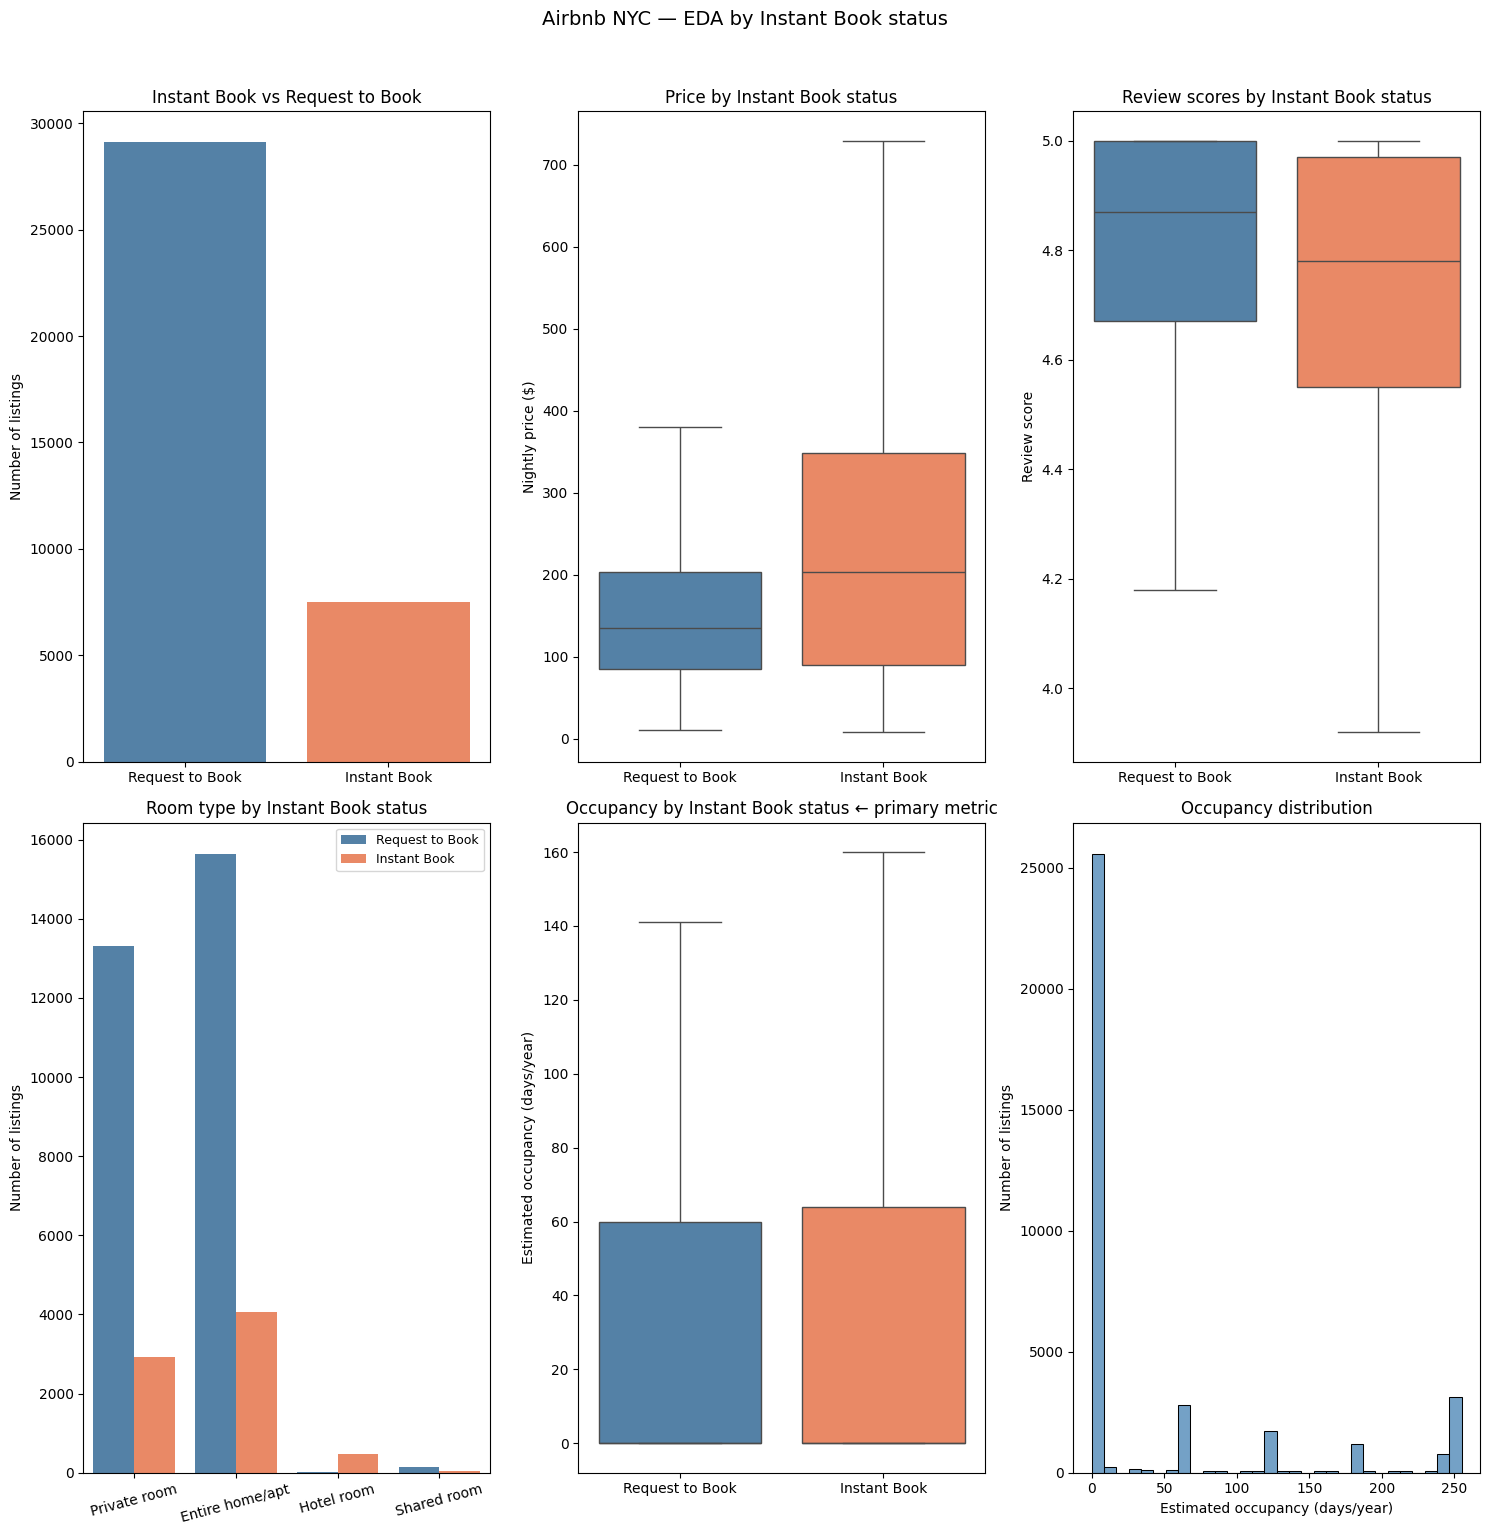

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(15, 15))
fig.suptitle('Airbnb NYC — EDA by Instant Book status', fontsize=14, y=1.02)
# Plot 1 — Instant Book breakdown
sns.countplot(data=listings_clean, x= 'ib_label', hue ='ib_label',
              palette=['steelblue', 'coral'], ax=axes[0,0])
axes[0,0].set_title('Instant Book vs Request to Book')
axes[0,0].set_xlabel('')
axes[0,0].set_ylabel('Number of listings')

 # Plot 2 — Price by Instant Book status
sns.boxplot(data=listings_clean, x='ib_label', y='price', hue='ib_label',
            palette=['steelblue', 'coral'], legend=False, ax=axes[0,1],
            showfliers=False)
axes[0,1].set_title('Price by Instant Book status')
axes[0,1].set_xlabel('')
axes[0,1].set_ylabel('Nightly price ($)')

# Plot 3 — Review scores by Instant Book status
reviewed = listings_clean[listings_clean['has_reviews']]
sns.boxplot(data=reviewed, x='ib_label', y='review_scores_rating', hue='ib_label',
            palette=['steelblue', 'coral'], legend=False, ax=axes[0,2],
            showfliers=False)
axes[0,2].set_title('Review scores by Instant Book status')
axes[0,2].set_xlabel('')
axes[0,2].set_ylabel('Review score')

# Plot 4 — Room type by Instant Book status
sns.countplot(data=listings_clean, x='room_type', hue='ib_label',
              palette=['steelblue', 'coral'], ax=axes[1,0])
axes[1,0].set_title('Room type by Instant Book status')
axes[1,0].set_xlabel('')
axes[1,0].set_ylabel('Number of listings')
axes[1,0].tick_params(axis='x', rotation=15)
axes[1,0].legend(title='', fontsize=9)

# Plot 5 — Occupancy by Instant Book status
sns.boxplot(data=listings_clean, x='ib_label', y='estimated_occupancy_l365d',
            hue='ib_label', palette=['steelblue', 'coral'], legend=False,
            ax=axes[1,1], showfliers=False)
axes[1,1].set_title('Occupancy by Instant Book status ← primary metric')
axes[1,1].set_xlabel('')
axes[1,1].set_ylabel('Estimated occupancy (days/year)')

# Plot 6 — Occupancy distribution overall
sns.histplot(data=listings_clean, x='estimated_occupancy_l365d',
             bins=30, ax=axes[1,2], color='steelblue')
axes[1,2].set_title('Occupancy distribution')
axes[1,2].set_xlabel('Estimated occupancy (days/year)')
axes[1,2].set_ylabel('Number of listings')

plt.tight_layout()
plt.show()

## EDA findings

**Plot 1 — Group imbalance between Request to book vs Instant Book:**
Instant Book listings represent only 20.5% of all listings (7,505 vs 
29,108). This 80/20 imbalance means direct comparison would be 
unreliable — motivates propensity score matching in Notebook 2.

**Plot 2 — Price difference:**
Instant Book listings are more expensive for nightly prices (median ~$200 vs ~$120, 
wider spread up to $350+) and a wider range. Price is significant — 
higher priced listings may attract different guest behaviour 
independent of the Instant Book feature. 

**Plot 3 — Review score difference:**
Request to Book listings have higher, more consistent review scores 
(median median 4.85, tight IQR). Instant Book listings show lower median (4.78) and much wider variance down to 3.8 — suggesting more 
variable listing quality. 

**Plot 4 — Room type imbalance:**
Instant Book skews toward hotels compared 
to Request to Book skewing towards private room and entire home/apt. Entire homes have systematically different 
booking patterns.

**Plot 5 — Pre-existing occupancy difference:**
Instant Book listings already show slightly higher occupancy 
(median ~65 vs ~60 days/year) before any experiment intervention. 

**Plot 6 — Occupancy distribution:**
Heavily right-skewed with most listings near 0 days occupancy with a spike 
of over ~25,000 listings suggesting a data ceiling. 

**Overall conclusion:**
Instant Book and non-Instant Book listings differ systematically 
on price, review scores, room type, and baseline occupancy. 
Direct comparison would produce biased results. Propensity score 
matching on these four variables is required before experiment analysis.

## Baseline occupancy rate

In [25]:
# Baseline occupancy rate from estimated_occupancy_l365d
baseline_rate = (listings_clean['estimated_occupancy_l365d'] / 365).mean()
print(f'Baseline occupancy rate: {baseline_rate:.4f} ({baseline_rate:.2%})')

# Split by instant book status
baseline_by_group = (
    listings_clean
    .assign(occupancy_rate=listings_clean['estimated_occupancy_l365d'] / 365)
    .groupby('instant_bookable')['occupancy_rate']
    .mean()
    .reset_index()
)
baseline_by_group['instant_bookable'] = baseline_by_group['instant_bookable'].map(
    {True: 'Instant Book', False: 'Request to Book'}
)
print(f'\nBaseline by group:\n{baseline_by_group}')

Baseline occupancy rate: 0.1279 (12.79%)

Baseline by group:
  instant_bookable  occupancy_rate
0  Request to Book        0.120588
1     Instant Book        0.156125


### Baseline occupancy rate

**Overall baseline: 12.79%**
Used as the baseline conversion rate for power analysis.

**Finding — counterintuitive group difference:**
Raw occupancy rates show Request to Book listings 
have slightly lower occupancy (12.06%) than 
Instant Book listings (15.61%). This is the 
of the expected direction.

Calendar-based (pooled across all listing-days):
- Heavily weighted toward listings with lots of activity
- Request to Book listings dominate volume → pulls the RTB rate up

estimated_occupancy_l365d (per-listing average):
- Each listing counted once regardless of activity level  
- Instant Book listings average higher per-listing occupancy

## Power Test

In [32]:
def calculate_sample_size(baseline_rate, mde, alpha=0.05, power=0.80):
    """
    Calculate required sample size per group for a two-proportions z-test.
    
    Formula:
        baseline_rate : control group conversion rate
        mde           : minimum detectable effect (absolute)
        alpha         : significance level (default 0.05)
        power         : statistical power (default 0.80)
    
    Returns:
        n : required sample size per group
    """
    # Treatment rate
    treatment_rate = baseline_rate + mde
    
    # Z scores
    z_alpha = stats.norm.ppf(1 - alpha / 2)  # two-tailed
    z_beta  = stats.norm.ppf(power)
    
    # Variances
    var_control   = baseline_rate * (1 - baseline_rate)
    var_treatment = treatment_rate * (1 - treatment_rate)
    
    # Sample size formula
    n = ((z_alpha + z_beta) ** 2 * (var_control + var_treatment)) / (mde ** 2)
    
    return ceil(n)

# Experiment parameters
BASELINE_RATE = 0.1279
MDE           = 0.017
ALPHA         = 0.05
POWER         = 0.80

n = calculate_sample_size(BASELINE_RATE, MDE, ALPHA, POWER)

print("-" * 45)
print("Power analysis results")
print("-" * 45)
print(f"Baseline conversion rate  : {BASELINE_RATE:.4f} ({BASELINE_RATE:.2%})")
print(f"Treatment rate (expected) : {BASELINE_RATE + MDE:.4f} ({BASELINE_RATE + MDE:.2%})")
print(f"Minimum detectable effect : {MDE:.2%}")
print(f"Significance level (α)    : {ALPHA}")
print(f"Statistical power (1-β)   : {POWER:.0%}")
print(f"Z_alpha                   : {stats.norm.ppf(1 - ALPHA/2):.3f}")
print(f"Z_beta                    : {stats.norm.ppf(POWER):.3f}")
print("-" * 45)
print(f"Required n per group      : {n:,}")
print(f"Total required            : {n*2:,}")
print("-" * 45)

 # Check against available listings
instant_book_count = listings_clean['instant_bookable'].sum()
request_book_count = (~listings_clean['instant_bookable']).sum()

print(f"\nAvailable listings:")
print(f"Instant Book    : {instant_book_count:,}")
print(f"Request to Book : {request_book_count:,}")
print(f"\nHave enough?")
print(f"Instant Book    : {'Yes' if instant_book_count >= n else 'Not enough'}")
print(f"Request to Book : {'Yes' if request_book_count >= n else 'Not enough'}")

---------------------------------------------
Power analysis results
---------------------------------------------
Baseline conversion rate  : 0.1279 (12.79%)
Treatment rate (expected) : 0.1449 (14.49%)
Minimum detectable effect : 1.70%
Significance level (α)    : 0.05
Statistical power (1-β)   : 80%
Z_alpha                   : 1.960
Z_beta                    : 0.842
---------------------------------------------
Required n per group      : 6,395
Total required            : 12,790
---------------------------------------------

Available listings:
Instant Book    : 7,505
Request to Book : 29,108

Have enough?
Instant Book    : Yes
Request to Book : Yes


### Power analysis

###  corrected baseline

Baseline rate corrected from 57.61% (calendar pooled) to 
12.79% (estimated_occupancy_l365d, per-listing average) — 
matches the actual outcome metric used in the experiment.

The lower baseline (further from 50% maximum variance) 
reduced the required sample size, allowing MDE to tighten 
from 2.5% to 1.7%.

| Parameter | Value |
|---|---|
| Baseline occupancy | 12.79% |
| MDE | 1.7pp |
| Required n per group | 6,395 |
| Instant Book available | 7,505 |

1.7pp represents ~7 additional booked days per year per listing 
— a meaningful lift that's detectable with available sample size.

# Exporting Clean Data 

In [27]:

# Create data directory if it doesn't exist
os.makedirs('data', exist_ok=True)

# Export clean datasets
listings_clean.to_csv('data/listings_clean.csv', index=False)
calendar_clean.to_csv('data/calendar_clean.csv', index=False)

print(f'listings_clean exported: {listings_clean.shape}')
print(f'calendar_clean exported: {calendar_clean.shape}')

listings_clean exported: (36613, 22)
calendar_clean exported: (13495986, 6)
